Subdiagonal (A): [1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1.]
Right-hand side (D): [-12.  12. -12.  12.]
Second derivatives (M): [ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


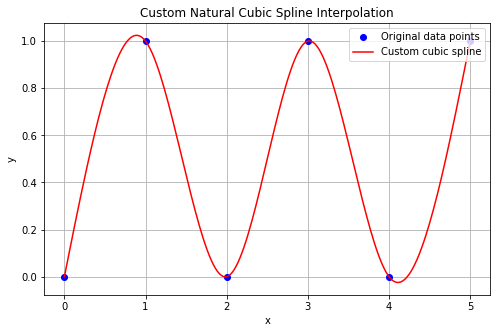

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_data = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_data = np.array([0, 1, 0, 1, 0, 1], dtype=float)

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)  # subdiagonal
    B = np.zeros(n - 2)  # main diagonal
    C = np.zeros(n - 2)  # superdiagonal
    D = np.zeros(n - 2)  # right-hand side

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - ((y[i] - y[i - 1]) / h[i - 1]))

    return A, B, C, D


def thomas_algorithm(a, b, c, d):
    n = len(b)

    a = a.astype(float).copy()
    b = b.astype(float).copy()
    c = c.astype(float).copy()
    d = d.astype(float).copy()

    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x

def evaluate_spline(x_data, y_data, M, x_query):
    n = len(x_data)
    h = np.diff(x_data)

    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2)

    hi = h[i]
    dx_left = x_query - x_data[i]
    dx_right = x_data[i + 1] - x_query

    S = (
        (M[i] / (6 * hi)) * dx_right**3 +
        (M[i + 1] / (6 * hi)) * dx_left**3 +
        (y_data[i] / hi - M[i] * hi / 6) * dx_right +
        (y_data[i + 1] / hi - M[i + 1] * hi / 6) * dx_left
    )

    return S


A, B, C, D = setup_tridiagonal_matrix(x_data, y_data)

M_interior = thomas_algorithm(A[:-1], B, C[:-1], D)

M = np.zeros(len(x_data))
M[1:-1] = M_interior

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)
print("Second derivatives (M):", M)

x_interp = np.linspace(x_data[0], x_data[-1], 200)
y_interp = np.array([evaluate_spline(x_data, y_data, M, xq) for xq in x_interp])

plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'bo', label="Original data points")
plt.plot(x_interp, y_interp, 'r-', label="Custom cubic spline")
plt.title("Custom Natural Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# AI USAGE DISCLOSURE:
# I used ChatGPT to double-check my Python syntax and help organize the code
# for setting up the tridiagonal system, solving it with the Thomas algorithm,
# and evaluating the cubic spline. The spline method, natural boundary conditions,
# and piecewise formula come from the lecture slides and in-class examples.
#
# AI Tool Used: ChatGPT
# Prompt Used:
# "Help me implement a natural cubic spline interpolation from scratch using the
# tridiagonal system, Thomas algorithm, and spline evaluation formula."
